# A-RoF ARVTDNN-DPD

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent)

sys.path.append(project_path)

In [17]:
project_path

'C:\\Users\\PC\\Documents\\dpd_repo'

In [3]:
import numpy as np
import torch as th

from dpd.models import ARVTDNN, ETDNN, ETDKAN, MP
from dpd.torchUtils import slidingWindowMP, MP_filter, fitFilterNN, fitFilterNN_v2
from dpd.nn import trainNN, trainMP

In [4]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, finddelay, decimate, upsample, clockSamplingInterp
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W

In [5]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Importação do sinal Tx

In [6]:
symbTx   = np.loadtxt(file_path + r"\transmittedSignal\symbTx.txt", dtype = np.complex64)
symbRx   = np.loadtxt(file_path + r"\transmittedSignal\symbRx.txt", dtype = np.complex64)
sigTx_ref = np.loadtxt(file_path + r"\transmittedSignal\sigTx.txt", dtype = np.complex64)
sigRx_PA  = np.loadtxt(file_path + r"\transmittedSignal\sigRx_PA.txt", dtype = np.complex64)

In [7]:
with open(file_path + r'\transmittedSignal\paramOFDM.pkl', 'rb') as f:
    paramOFDM = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramRF.pkl', 'rb') as f:
    paramRF = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramMZM.pkl', 'rb') as f:
    paramMZM = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramChannel.pkl', 'rb') as f:
    paramChannel = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramPD.pkl', 'rb') as f:
    paramPD = pickle.load(f)
    f.close()

### 2 Identificação do canal

In [8]:
SpS_DPD = 4
SpS = paramOFDM.SpS
Rs  = paramOFDM.Rs
Fs  = paramOFDM.Fs
gain_pre_MZM, gain_pre_PA = paramOFDM.gain_pre_MZM_PA

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_DPD

numtaps = 4096
hlp = firwin(numtaps, SpS_DPD*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx_ref)), paramDec).ravel()
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).ravel()

In [9]:
delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

In [10]:
# sigRef -> sinal de entrada do sistema
# sigIn -> sinal de saída de sistema (entrada do equalizador)

In [10]:
paramModel = parameters()
paramModel.model_name = "ARVTDNN"
paramModel.K = 3
paramModel.M = 3
paramModel.hidden_layers = [16]
paramModel.activation = "relu"

paramTrain = parameters()
paramTrain.trainTestFrac = 0.75
paramTrain.batchSize     = 1_000
paramTrain.shuffle       = False
paramTrain.adaptLearningRatio = True
paramTrain.lr      = 5e-3
paramTrain.epochs  = 500
paramTrain.pgrsBar = True
paramTrain.device  = "cuda" # "cpu"

model, trainLoss, testLoss = trainNN(th.from_numpy(sigIn[0:50_000]).to(paramTrain.device).type(th.complex64),  \
                                     th.from_numpy(sigRef[0:50_000]).to(paramTrain.device).type(th.complex64), \
                                     paramTrain, paramModel)

  0%|          | 0/500 [00:00<?, ?it/s]

In [26]:
paramModel = parameters()
paramModel.model_name = "ETDNN"
paramModel.N = 10
paramModel.M = 1
paramModel.activation = "relu"

paramTrain = parameters()
paramTrain.trainTestFrac = 0.75
paramTrain.batchSize     = 1_000
paramTrain.shuffle       = False
paramTrain.adaptLearningRatio = True
paramTrain.lr      = 5e-3
paramTrain.epochs  = 500
paramTrain.pgrsBar = True
paramTrain.device  = "cuda" # "cpu"

model, trainLoss, testLoss = trainNN(th.from_numpy(sigIn[0:50_000]).to(paramTrain.device).type(th.complex64),  \
                                     th.from_numpy(sigRef[0:50_000]).to(paramTrain.device).type(th.complex64), \
                                     paramTrain, paramModel)

  0%|          | 0/500 [00:00<?, ?it/s]

In [25]:
paramModel = parameters()
paramModel.model_name = "ETDKAN"
paramModel.N = 1
paramModel.M = 1
paramModel.k = 2
paramModel.grid = 2
paramModel.seed = 0

paramTrain = parameters()
paramTrain.trainTestFrac = 0.75
paramTrain.batchSize     = 1_000
paramTrain.shuffle       = False
paramTrain.adaptLearningRatio = True
paramTrain.lr      = 5e-3
paramTrain.epochs  = 100
paramTrain.pgrsBar = True
paramTrain.device  = "cuda" # "cpu"
paramTrain.symbolicEpoch = 50

model, trainLoss, testLoss = trainNN(th.from_numpy(sigIn[0:50_000]).to(paramTrain.device).type(th.complex64),  \
                                     th.from_numpy(sigRef[0:50_000]).to(paramTrain.device).type(th.complex64), \
                                     paramTrain, paramModel)

  0%|          | 0/100 [00:00<?, ?it/s]

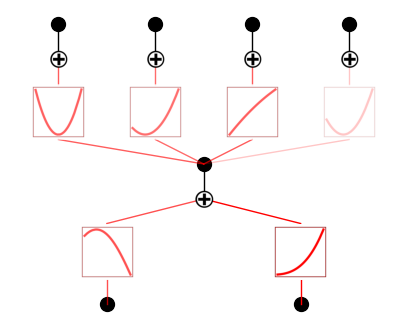

In [34]:
model2.KAN.plot()

In [33]:
#model.save(r"C:\Users\PC\Documents\dpd_repo\examples\test_saving_models\test_symb_etdkan")

model2 = ETDKAN(paramModel.M, paramModel.N, paramModel.k, paramModel.grid, paramModel.seed, paramTrain.device)
model2.load(r"C:\Users\PC\Documents\dpd_repo\examples\test_saving_models\test_symb_etdkan")

#model2 = ETDNN(paramModel.M, paramModel.N, nn.ReLU()).to("cuda")
#model2.load(r"C:\Users\PC\Documents\dpd_repo\examples\test_saving_models\test_etdnn.pth")



C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\kan\MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
C:\Users\PC\

In [21]:
from torch import nn

In [44]:
M = 3
indTaps = np.arange(0, (M + 1), dtype = np.int64)

In [50]:
start_idx = 0
end_idx = 100

sampleInd = np.arange(start_idx, end_idx, dtype=np.int64)
indIn = (-indTaps + sampleInd[:, None])

In [51]:
indIn

array([[ 0, -1, -2, -3],
       [ 1,  0, -1, -2],
       [ 2,  1,  0, -1],
       [ 3,  2,  1,  0],
       [ 4,  3,  2,  1],
       [ 5,  4,  3,  2],
       [ 6,  5,  4,  3],
       [ 7,  6,  5,  4],
       [ 8,  7,  6,  5],
       [ 9,  8,  7,  6],
       [10,  9,  8,  7],
       [11, 10,  9,  8],
       [12, 11, 10,  9],
       [13, 12, 11, 10],
       [14, 13, 12, 11],
       [15, 14, 13, 12],
       [16, 15, 14, 13],
       [17, 16, 15, 14],
       [18, 17, 16, 15],
       [19, 18, 17, 16],
       [20, 19, 18, 17],
       [21, 20, 19, 18],
       [22, 21, 20, 19],
       [23, 22, 21, 20],
       [24, 23, 22, 21],
       [25, 24, 23, 22],
       [26, 25, 24, 23],
       [27, 26, 25, 24],
       [28, 27, 26, 25],
       [29, 28, 27, 26],
       [30, 29, 28, 27],
       [31, 30, 29, 28],
       [32, 31, 30, 29],
       [33, 32, 31, 30],
       [34, 33, 32, 31],
       [35, 34, 33, 32],
       [36, 35, 34, 33],
       [37, 36, 35, 34],
       [38, 37, 36, 35],
       [39, 38, 37, 36],


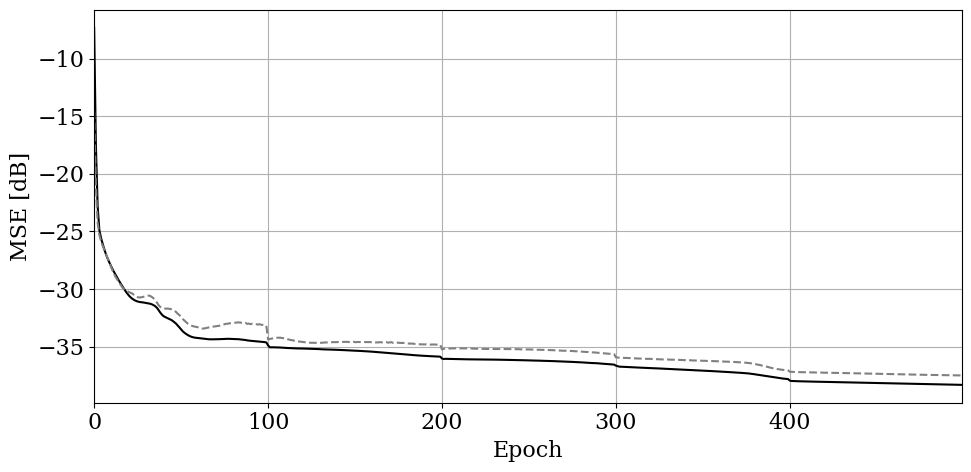

In [11]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k")
axs.plot(10*np.log10(testLoss), color = "gray", ls = "--")

axs.set_xlim(0, paramTrain.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
plt.tight_layout()

In [12]:
sig_model = fitFilterNN(th.from_numpy(sigIn).to(paramTrain.device).type(th.complex64), model, paramModel.M + 1, paramModel.K, 1, 100, augment = True, prgsBar = True)
sig_model = sig_model.detach().cpu().numpy()

100%|████████████████████████████████████████████████████████████████████████████| 1788/1788 [00:00<00:00, 3534.78it/s]


In [13]:
sig_model_v2 = fitFilterNN_v2(th.from_numpy(sigIn).to(paramTrain.device).type(th.complex64), \
                              model, paramTrain, paramModel, batchSize = 100, predict = True)

sig_model_v2 = sig_model_v2.detach().cpu().numpy()

In [14]:
delay = finddelay(sig_model_v2, sig_model)
delay

0

MSE = -32.222 dB
MSE = -32.222 dB


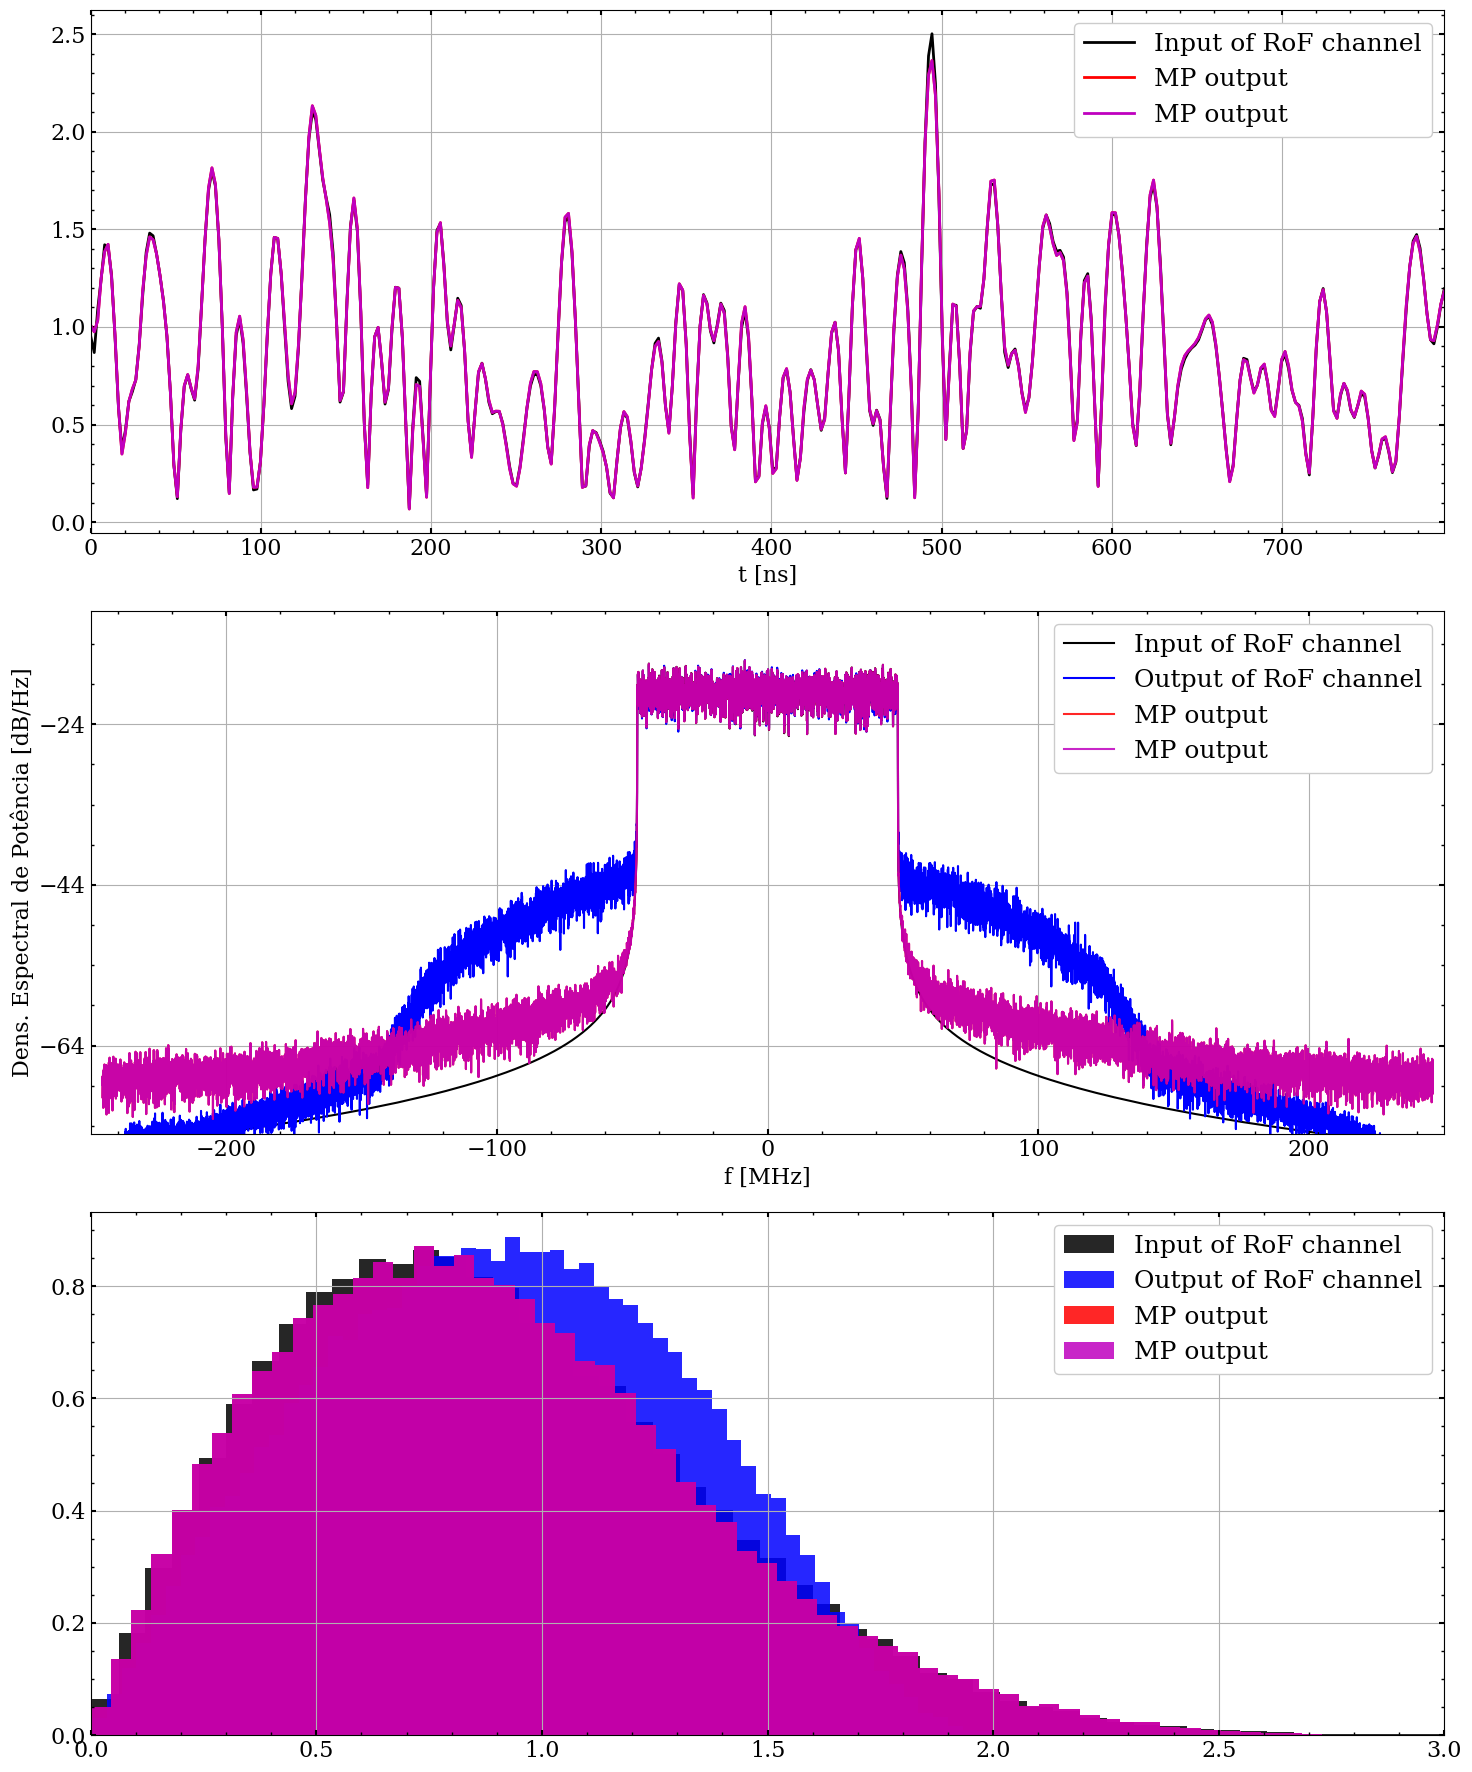

In [15]:
indx = np.arange(0, int(10000*SpS_DPD/SpS))
#indx = np.arange(sigRef.size - int(10000*SpS_DPD/SpS), sigRef.size)

fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_DPD)

print(f"MSE = {10*np.log10(np.mean(np.abs(np.roll(sig_model, 0) - sigRef)**2)):.3f} dB")
print(f"MSE = {10*np.log10(np.mean(np.abs(np.roll(sig_model_v2, 0) - sigRef)**2)):.3f} dB")

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "Input of RoF channel")
#axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_model[indx]), "r", lw = 2, label = "MP output")
axs[0].plot(t[indx]*1e9, np.abs(np.roll(sig_model_v2, 0)[indx]), "m", lw = 2, label = "MP output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef, Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_model, Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "r", label = "MP output", alpha = 0.85)
axs[1].psd(sig_model_v2, Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "m", label = "MP output", alpha = 0.85)

axs[1].set_xlabel("f [MHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-250, 250)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_model), density = True, bins = 64, color = "r", label = 'MP output', alpha = 0.85)
axs[2].hist(np.abs(sig_model_v2), density = True, bins = 64, color = "m", label = 'MP output', alpha = 0.85)

axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

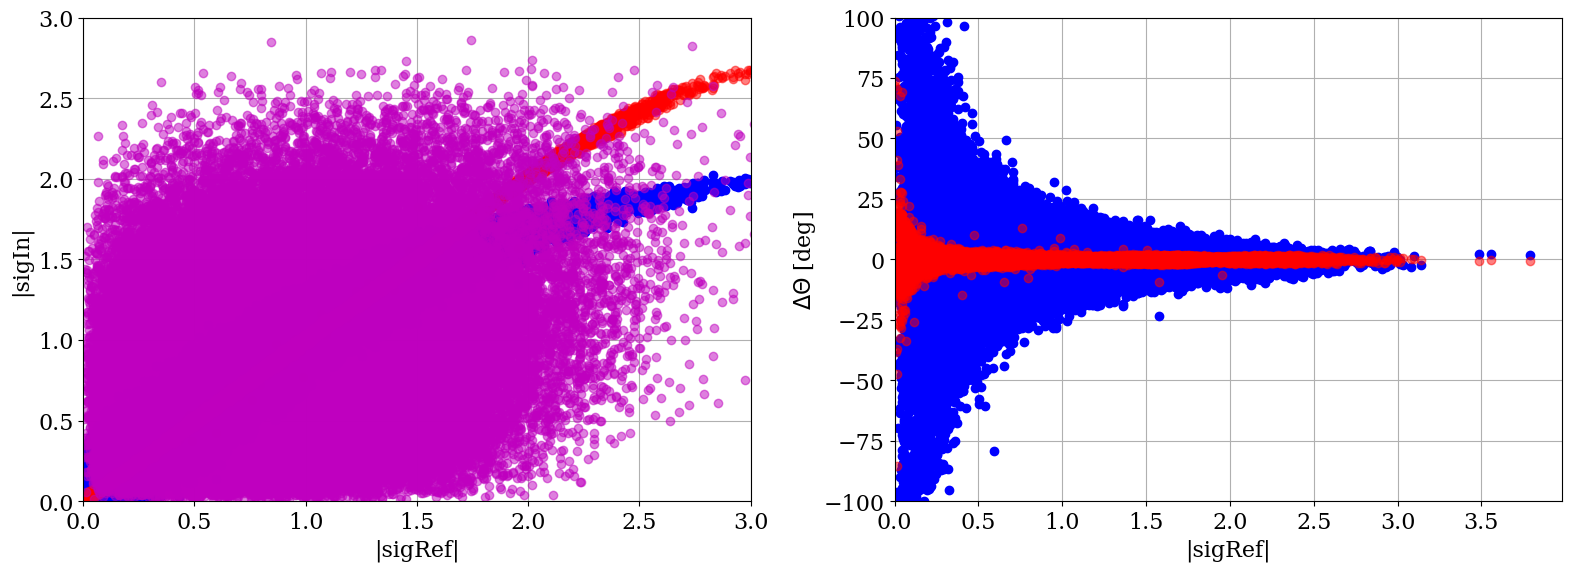

In [16]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sigIn[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sig_model[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(np.roll(sig_model_v2, -3)[0:n_pts]), "o", color = "m", alpha = 0.5)

axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sigIn) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sig_model) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()

### 3 - Arquitetura de Aprendizado Indireto (ILA)

In [14]:
paramDPD = parameters()
paramDPD.M = M
paramDPD.P = P

paramDPD.N = 37_500
paramDPD.numIter = 5

paramDPD.mu  = 1e-3
paramDPD.lbd = 0.9999
paramDPD.S   = np.eye(paramDPD.P*paramDPD.M, dtype = complex)*5e-2

paramDPD.alg = "RLS"
paramDPD.a_kl = a_kl
paramDPD.directLearn = False

paramDPD.pgrsBar    = True
paramDPD.showMSE    = False
paramDPD.storeCoeff = True

DPD, errSq, w_hist, errSq_hist = MP_training(sigRef, paramDPD, sigIn)

  0%|          | 0/5 [00:00<?, ?it/s]

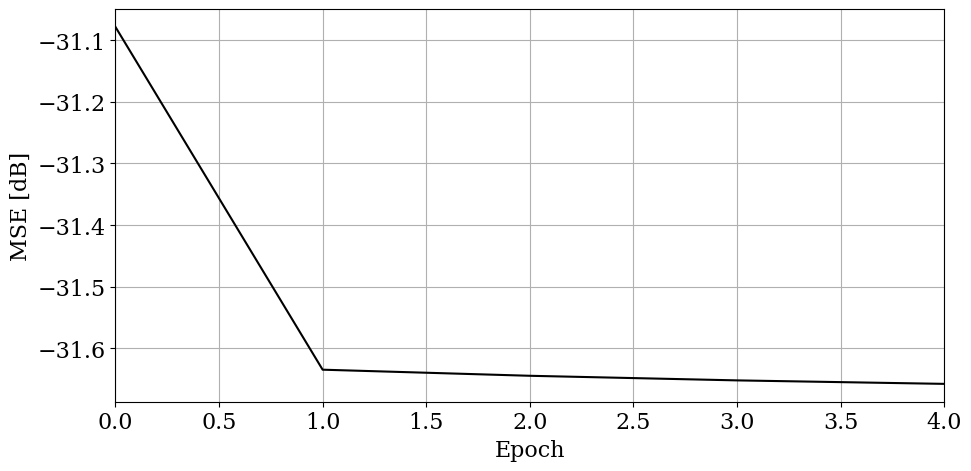

In [15]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(errSq_hist), color = "k")

axs.set_xlim(0, paramDPD.numIter - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
plt.tight_layout()

In [16]:
sig_mp = MP_filter(sigIn, np.conj(DPD).reshape( (P, M) ) )

MSE = -31.659 dB


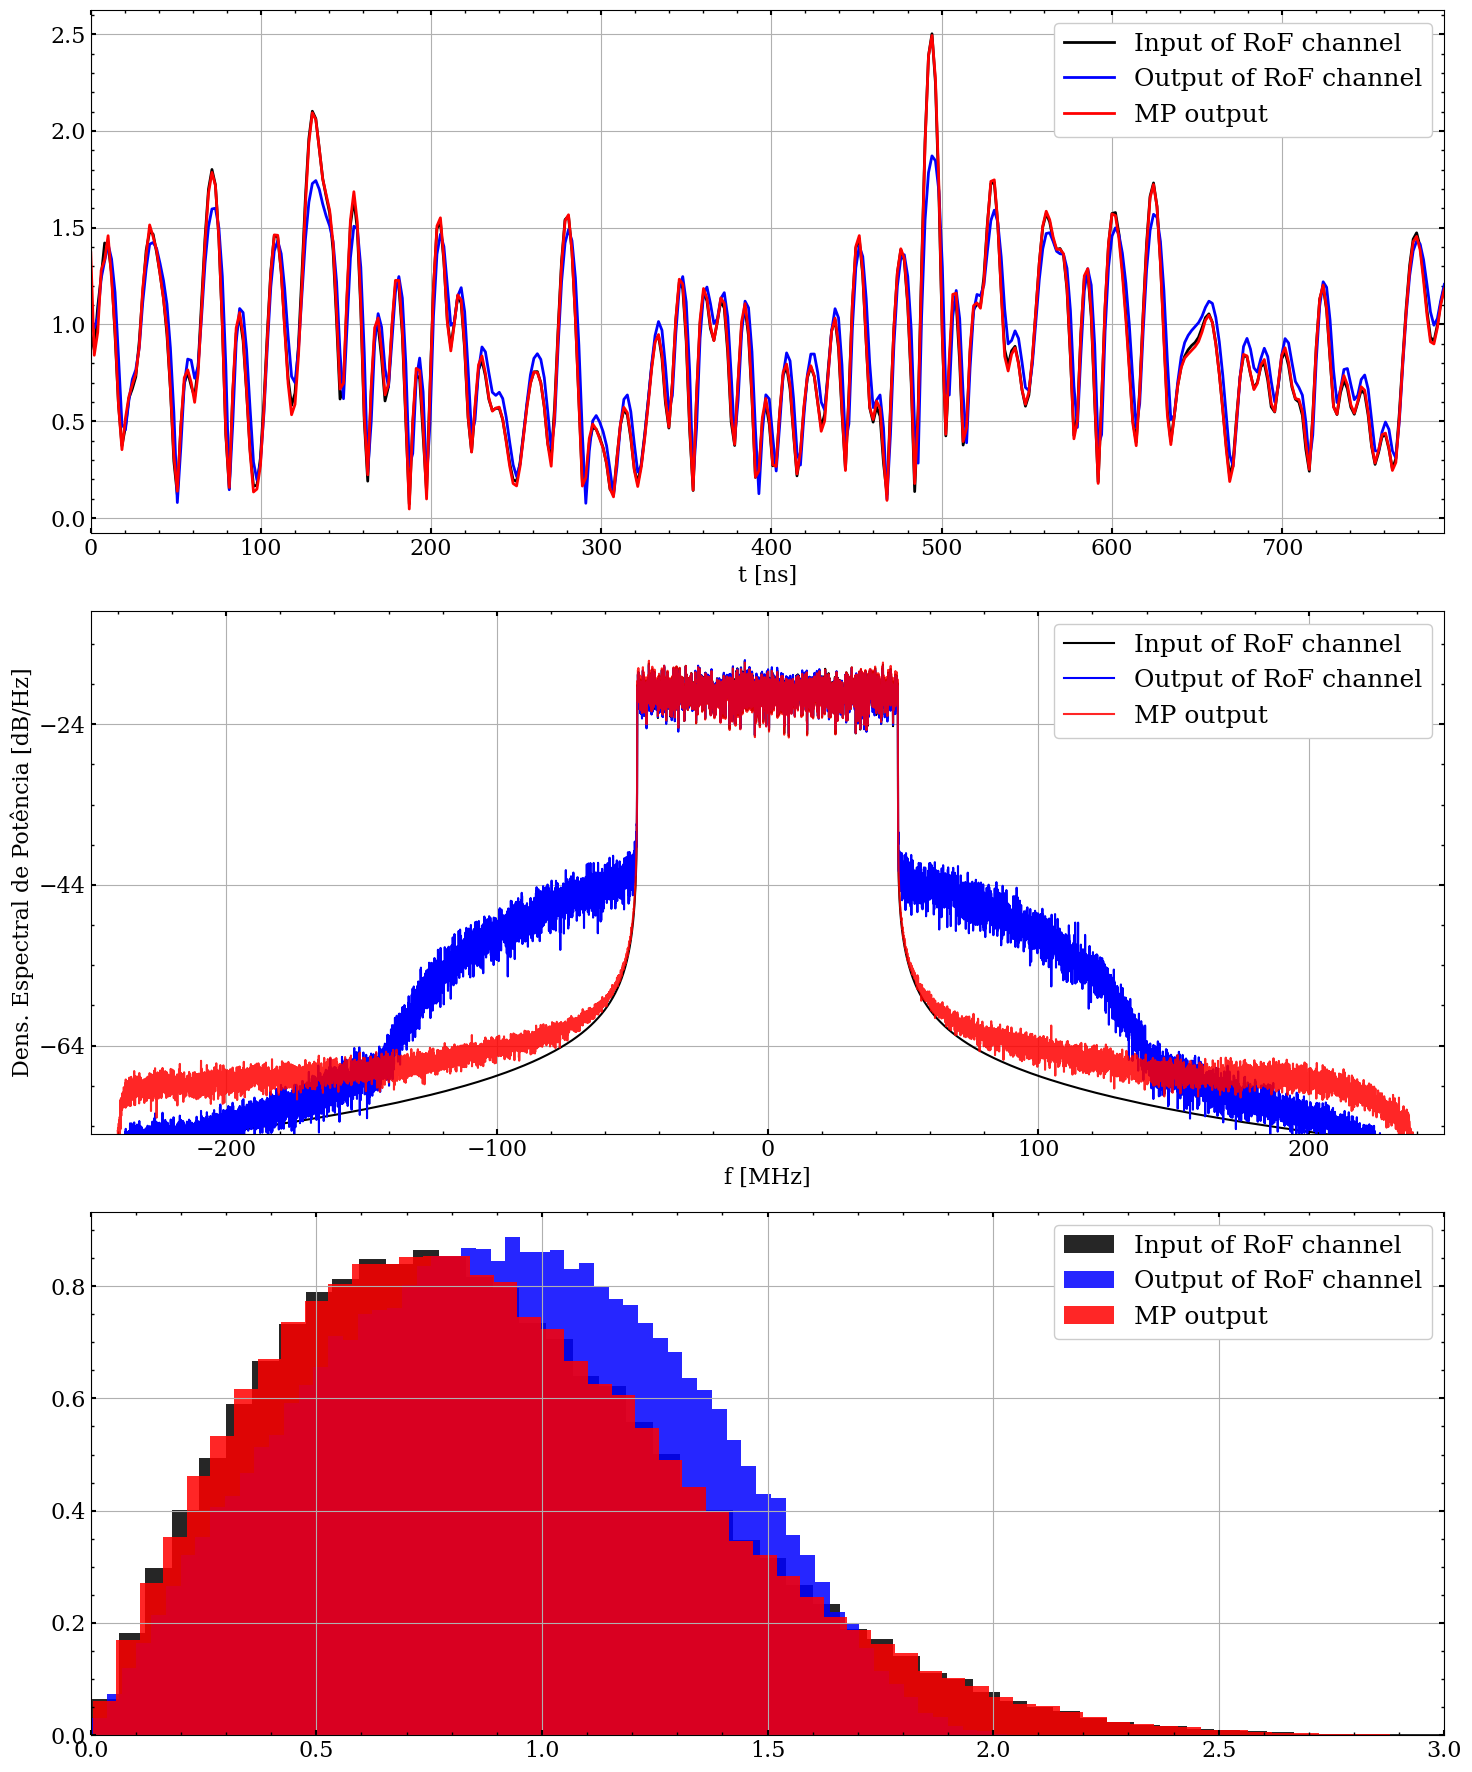

In [17]:
print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigRef)**2)):.3f} dB")

indx = np.arange(0, int(10000*SpS_DPD/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_DPD)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), "r", lw = 2, label = "MP output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef, Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_mp, Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "r", label = "MP output", alpha = 0.85)
axs[1].set_xlabel("f [MHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-250, 250)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, color = "r", label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

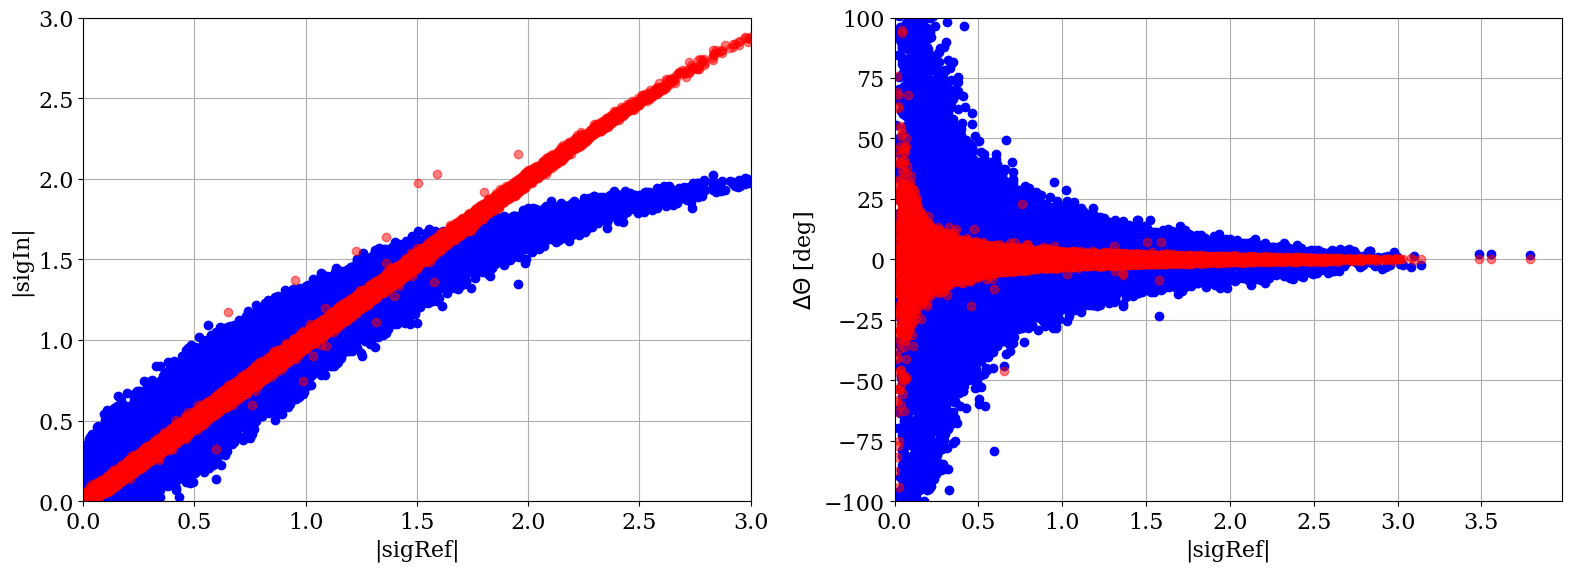

In [18]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sigIn[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sig_mp[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sigIn) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sig_mp) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()


### 5 - DPD Test

In [19]:
paramOFDM.SpS = SpS_DPD

sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

sigTx_DPD = MP_filter(sigTx, np.conj(DPD).reshape((P, M)))
gain_DPD  = np.sqrt(signal_power(sigTx_DPD))

In [20]:
numtaps = 4096
h_dpd = firwin(numtaps, 2*Rs, fs = Fs)

sigTx_DPD = clockSamplingInterp(sigTx_DPD.reshape(-1, 1), Fs*SpS_DPD/SpS, Fs).ravel()
sigTx_DPD = firFilter(h_dpd, sigTx_DPD)
sigTx_DPD = pnorm(sigTx_DPD)

t = np.arange(0, sigTx_DPD.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

#### 6.1 Sinal RF

In [21]:
sigTx_RF = np.real( sigTx_DPD * gain_DPD * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF *= gain_pre_MZM
sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)

print(f"Power at MZM's input with DPD: {10*np.log10(1e3*signal_power(sigTx_RF)):.3f} dBm")

Power at MZM's input with DPD: 18.061 dBm


#### 6.2 Sinal óptico

In [22]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo  = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

print(f"P_Txo = {10*np.log10(signal_power(sigTxo)*1e3):.3f} dBm")
print(f"P_Rxo = {10*np.log10(signal_power(sigRxo)*1e3):.3f} dBm")

P_Txo = 6.990 dBm
P_Rxo = 1.990 dBm


#### 6.3 Sinal elétrico (fotocorrente)

In [23]:
I_Rx  = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

#### 6.4 Sinal elétrico pós-FPF

In [24]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

#### 6.5 Sinal elétrico pós-PA

In [25]:
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx *= gain_pre_PA

print(f"Power at PA's input: {10*np.log10(1e3*signal_power(sigRx)):.3f} dBm")

sigRx = power_amplifier(sigRx)
sigRx_PA_DPD = sigRx.copy()
sigRx_PA_DPD = pnorm(sigRx_PA_DPD)

numtaps = 4096
hlp   = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx)

delay = finddelay(sigRx, sigTx_DPD)
sigRx = np.roll(sigRx, -delay)

rot   = np.mean(sigTx_DPD/sigRx)
sigRx = rot/np.abs(rot)*sigRx

Power at PA's input: 5.655 dBm


#### Perfomance

In [26]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1
samples_per_frame = SpS * (paramOFDM.Nfft + paramOFDM.G)

symbRx_OFDM = sigRx.copy()[0::SpS][0:paramOFDM.numOFDMframes*(paramOFDM.Nfft + paramOFDM.G)]
symbRx_DPD  = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00000 
SNR = 30.263 dB 
EVM = 3.069 %


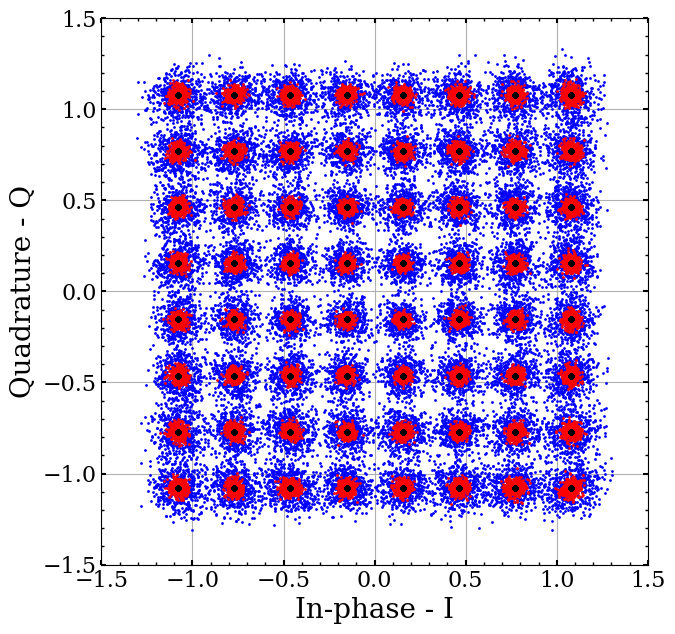

In [27]:
discard = 100
index = np.arange(0, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD[index], symbTx[index], paramOFDM.modOrder, paramOFDM.modType)

EVM = np.sqrt(calcEVM(symbRx_DPD[index], paramOFDM.modOrder, paramOFDM.modType, symbTx[index]))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD = pnorm(symbRx_DPD)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx[index].real, symbRx[index].imag, "o", color = "b", ms = 1)
axs.plot(symbRx_DPD[index].real, symbRx_DPD[index].imag, "o", color = "r", ms = 1)
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3)
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.grid()
plt.tight_layout()
#plt.savefig("constelacao_nnDPD.png")

In [28]:
freq, P_sigTx        = welch(pnorm(sigTx), fs = SpS_DPD*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA     = welch(pnorm(sigRx_PA)[0::SpS//SpS_DPD], fs = SpS_DPD*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD = welch(pnorm(sigRx_PA_DPD)[0::SpS//SpS_DPD], fs = SpS_DPD*Rs, nfft = 16*1024, return_onesided = False)

SigTx - ACLR = -42.932 dB
SigRx PA w/o DPD - ACLR = -28.263 dB
SigRx PA w DPD - ACLR = -36.048 dB


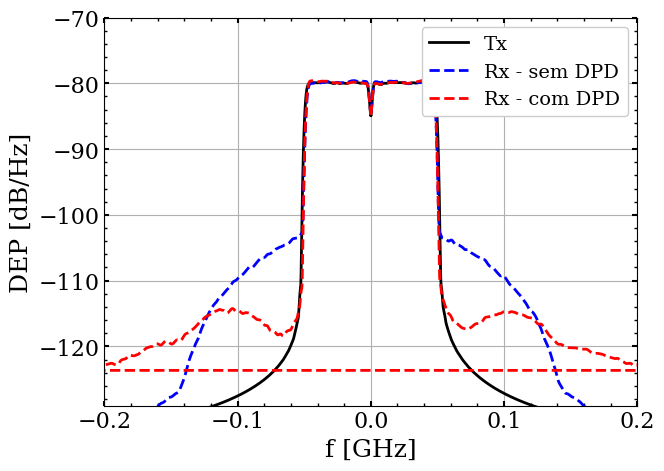

In [29]:
print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")
print(f"SigRx PA w DPD - ACLR = {calcACLR(P_sigRx_PA_DPD, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")

fig, axs = plt.subplots(1, 1, figsize = (7, 5))

axs.plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA), lw = 2, color = "b", label = "Rx - sem DPD", ls = "--")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD), lw = 2, color = "r", label = "Rx - com DPD", ls = "--")

axs.set_xlim(-0.2, 0.2)
axs.set_ylim(-129, -70)

axs.set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs.set_xlabel("f [GHz]", fontsize = 18)
axs.legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")